In [1]:
import pandas as pd
import numpy as np
from pybads import BADS
import matplotlib.pyplot as plt
import seaborn as sns
from potencial import get_expressions
from sim_helpers_fit import simulate_path, make_drift
from sim_helpers_fit_numba import run_trial_numba

In [2]:
df = pd.read_csv('./datasets/df_filtered.csv', sep = ';')
# Count rows per subject
subject_counts = df['subject'].value_counts()
print("Number of rows per subject:")
print(subject_counts)
# Calculate percentage of rows with timepoint_4 > 5 for each subject
timepoint_high_pct = {}
for subject in df['subject'].unique():
    subject_df = df[df['subject'] == subject]
    high_timepoint = subject_df[subject_df['timepoint_4'] > 7.5].shape[0]
    total = subject_df.shape[0]
    timepoint_high_pct[subject] = (high_timepoint / total) * 100

# Convert to Series for better display
timepoint_high_series = pd.Series(timepoint_high_pct)
print("\nPercentage of rows with timepoint_4 > 7.5s by subject:")
print(timepoint_high_series)
# Summary statistics
print("\nSummary statistics:")
print(f"Total subjects: {len(subject_counts)}")
print(f"Average rows per subject: {subject_counts.mean():.2f}")
print(f"Minimum rows per subject: {subject_counts.min()}")
print(f"Maximum rows per subject: {subject_counts.max()}")

# df = df[df['timepoint_4']<=5]


Number of rows per subject:
subject
A92    91004
A86    83540
A87    81338
A88    63807
A89    52668
A83    48920
A96    48584
A93    45190
A84    44880
A95    43483
A90    41627
A91    25470
Name: count, dtype: int64

Percentage of rows with timepoint_4 > 7.5s by subject:
A83    1.430908
A84    7.018717
A86    0.767297
A87    1.035187
A88    1.979407
A89    2.183489
A90    3.870084
A91    7.750294
A92    2.005406
A93    2.923213
A95    3.893476
A96    1.554010
dtype: float64

Summary statistics:
Total subjects: 12
Average rows per subject: 55875.92
Minimum rows per subject: 25470
Maximum rows per subject: 91004


In [3]:
print(df['timepoint_1'].describe())
print(len(df[df['timepoint_1']<0]))
df = df[df['timepoint_1'] > 0]  # Ensure timepoint_1 is positive
print(df['timepoint_2'].describe())
print(df['timepoint_3'].describe())
print(df['timepoint_4'].describe())


count    670511.000000
mean          0.613968
std           0.219594
min         -10.804100
25%           0.474100
50%           0.564100
75%           0.692700
max           2.528000
Name: timepoint_1, dtype: float64
34
count    670477.000000
mean          1.005888
std           0.278731
min           0.143500
25%           0.816200
50%           0.948400
75%           1.126900
max           2.948000
Name: timepoint_2, dtype: float64
count    670477.000000
mean          1.360058
std           0.338562
min           0.311200
25%           1.127200
50%           1.295900
75%           1.517900
max           2.999900
Name: timepoint_3, dtype: float64
count    670477.000000
mean          3.374446
std           2.610874
min           0.695000
25%           2.408400
50%           2.952800
75%           3.813300
max        1674.806100
Name: timepoint_4, dtype: float64


In [4]:
import os
import pickle
import pandas as pd
from fitting_numba_full import objective_function

params_folder = 'params_result'


param_names = [
    'sL', 'sC', 'sR', 'noise_amp', 'S_amplitude', 'S_d',
    'U_int_amplitude', 'U_int_baseline', 'U_int_onset', 'U_ext_amplitude'
]

rows = []

for filename in os.listdir(params_folder):
    if filename.startswith('result_') and filename.endswith('.pkl'):
        subject = filename.replace('result_', '').replace('.pkl', '')

        with open(os.path.join(params_folder, filename), 'rb') as f:
            result_obj = pickle.load(f)
        print(f'{result_obj.fval*100:.2f}')
        # Extraer el array de parámetros desde .x
        if hasattr(result_obj, 'x'):
            global_params = result_obj.x
        elif isinstance(result_obj, dict) and '.x' in result_obj:
            global_params = result_obj['.x']
        else:
            raise ValueError(f"No se encontró `.x` en {filename}")

        row = {'subject': subject}
        for name, val in zip(param_names, global_params):
            row[name] = val
        rows.append(row)

params_df = pd.DataFrame(rows)
params_df = params_df.sort_values(by='subject').reset_index(drop=True)
params_df.to_csv(f'{params_folder}/params_df.csv', index=False)


26.24
28.59
22.43
26.24
26.80
26.24
26.24
27.02
26.24
29.56
26.89
32.42
26.25
26.24
26.25


In [5]:
def strip_darken(ax):
    for collection in ax.collections:
        try:
            facecolors = collection.get_facecolors()
        except AttributeError:
            continue
        if len(facecolors) > 0:
            new_edgecolors = []
            for fc in facecolors:
                darkened = fc.copy()
                # Multiplicamos los valores RGB por 0.7 para oscurecer; ajustar si es necesario.
                darkened[:3] = darkened[:3] * 0.7
                new_edgecolors.append(darkened)
            collection.set_edgecolors(new_edgecolors)
            collection.set_linewidth(1.5)
    return

/var/folders/gk/r166p6nx2bb5zf2rlwww8fc00000gn/T/ipykernel_61224/4127173715.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_melted, x='parameter', y='value', palette='Set2')
/var/folders/gk/r166p6nx2bb5zf2rlwww8fc00000gn/T/ipykernel_61224/4127173715.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_melted, x='parameter', y='value', color='black', palette='Set2',alpha=0.5, jitter=True, ax = ax)


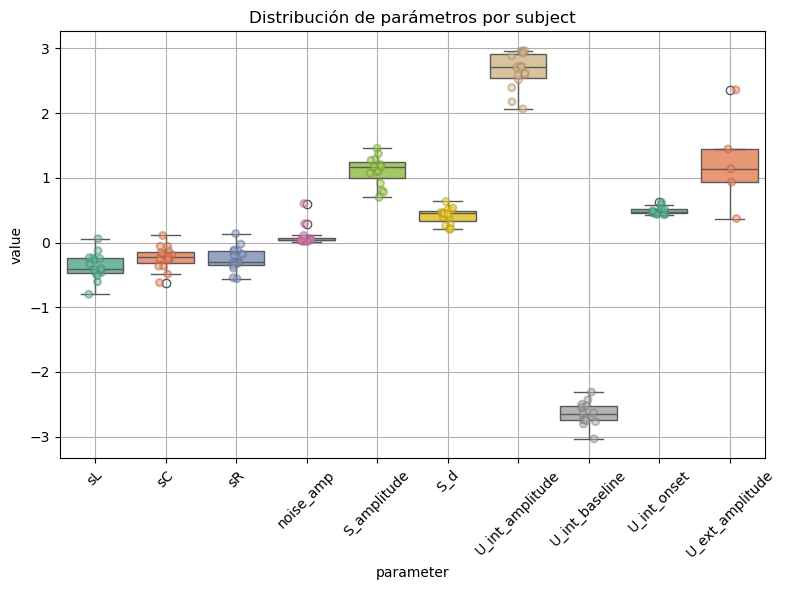

In [6]:
df_melted = params_df.melt(id_vars='subject', var_name='parameter', value_name='value')

# Boxplot
plt.figure(figsize=(8, 6))
ax = sns.boxplot(data=df_melted, x='parameter', y='value', palette='Set2')
sns.stripplot(data=df_melted, x='parameter', y='value', color='black', palette='Set2',alpha=0.5, jitter=True, ax = ax)
strip_darken(ax)
plt.title('Distribución de parámetros por subject')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
import os
import pickle
import pandas as pd
from fitting_numba_full import objective_function

params_folder = 'params_result'


param_names = [
    'sL', 'sC', 'sR', 'noise_amp', 'S_amplitude', 'S_d',
    'U_int_amplitude', 'U_int_baseline', 'U_int_onset'
]

rows = []

for filename in os.listdir(params_folder):
    if filename.startswith('result_A86_') and filename.endswith('.pkl'):
        subject = filename.replace('result_A86_', '').replace('.pkl', '')

        with open(os.path.join(params_folder, filename), 'rb') as f:
            result_obj = pickle.load(f)
        print(f'{result_obj.fval*100:.2f}')
        # Extraer el array de parámetros desde .x
        if hasattr(result_obj, 'x'):
            global_params = result_obj.x0[0]
        elif isinstance(result_obj, dict) and '.x' in result_obj:
            global_params = result_obj['.x']
        else:
            raise ValueError(f"No se encontró `.x0` en {filename}")

        row = {'subject': subject}
        for name, val in zip(param_names, global_params):
            row[name] = val
        rows.append(row)

x0_df = pd.DataFrame(rows)
x0_df = x0_df.sort_values(by='subject').reset_index(drop=True)



26.24
26.24
26.80
26.24
26.24
27.02
26.24
26.25
26.24
26.25


/var/folders/gk/r166p6nx2bb5zf2rlwww8fc00000gn/T/ipykernel_33848/3758958978.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_melted, x='parameter', y='value', palette='Set2')
/var/folders/gk/r166p6nx2bb5zf2rlwww8fc00000gn/T/ipykernel_33848/3758958978.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_melted, x='parameter', y='value', color='black', palette='Set2',alpha=0.5, jitter=True, ax = ax)


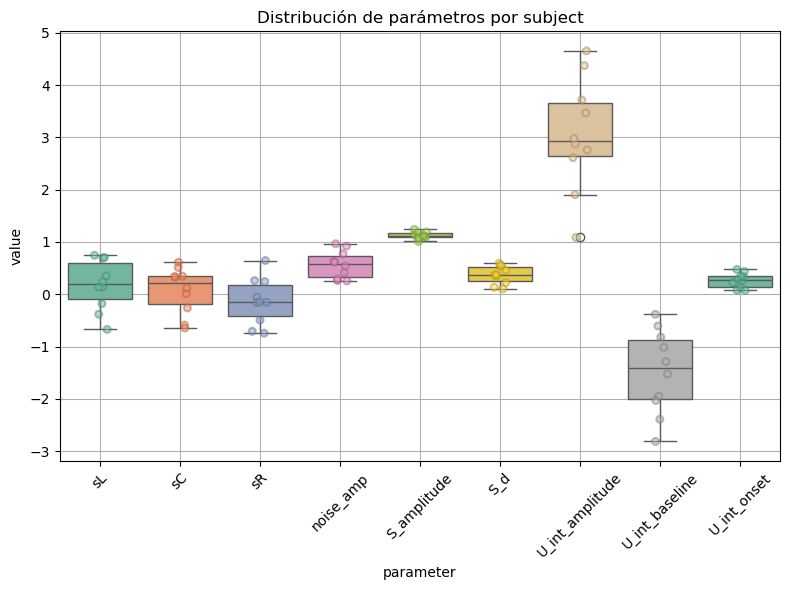

In [74]:
df_melted = x0_df.melt(id_vars='subject', var_name='parameter', value_name='value')

# Boxplot
plt.figure(figsize=(8, 6))
ax = sns.boxplot(data=df_melted, x='parameter', y='value', palette='Set2')
sns.stripplot(data=df_melted, x='parameter', y='value', color='black', palette='Set2',alpha=0.5, jitter=True, ax = ax)
strip_darken(ax)
plt.title('Distribución de parámetros por subject')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

/var/folders/gk/r166p6nx2bb5zf2rlwww8fc00000gn/T/ipykernel_33848/2857295346.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_melted, x='parameter', y='value', palette='Set2')
/var/folders/gk/r166p6nx2bb5zf2rlwww8fc00000gn/T/ipykernel_33848/2857295346.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_melted, x='parameter', y='value', color='black', palette='Set2',alpha=0.5, jitter=True, ax = ax)


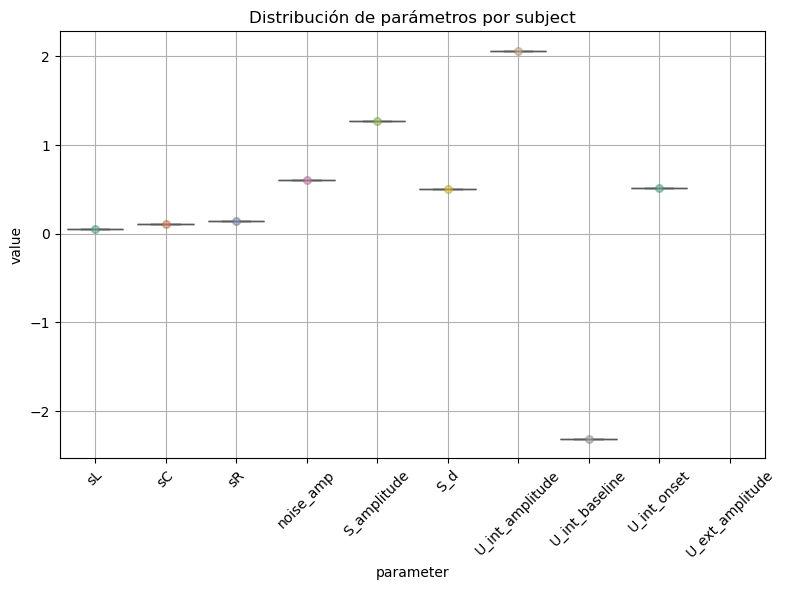

In [77]:
params_df_A86N = params_df[params_df['subject'].str.contains('A86_new_b')].copy()
df_melted = params_df_A86N.melt(id_vars='subject', var_name='parameter', value_name='value')

# Boxplot
plt.figure(figsize=(8, 6))
ax = sns.boxplot(data=df_melted, x='parameter', y='value', palette='Set2')
sns.stripplot(data=df_melted, x='parameter', y='value', color='black', palette='Set2',alpha=0.5, jitter=True, ax = ax)
strip_darken(ax)
plt.title('Distribución de parámetros por subject')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Subject: A87
  x0 : [[-0.33910026  0.67372835 -0.68866471  0.65053166  1.17920597  0.30355423
   1.51018532 -0.44496007  0.21324525  0.36435847]]
  diff: [[-0.0667516  -1.29234185  0.12922324 -0.61944316 -0.37422128 -0.01867121
   1.19986437 -2.29430082  0.27865176  0.56863445]]

Subject: A92
  x0 : [[ 0.55839592  0.65849231  0.61506904  0.27585709  1.19435737  0.7679765
   3.56055417 -2.24151102  0.27253196  0.30248697]]
  diff: [[-0.98571881 -0.71899489 -1.16063322 -0.16598941 -0.02596639 -0.55567721
  -1.38486574 -0.28124724  0.24470736  2.057848  ]]

Subject: A86
  x0 : [[-0.56381414 -0.21013572 -0.42285891  0.03317724  1.03279464  0.26621044
   2.22374771 -1.27438903  0.00678639  1.86027171]]
  diff: [[ 0.32539989  0.15147613  0.12442441  0.03023015 -0.11762    -0.00616846
   0.2922017  -1.27104589  0.42813579 -1.48912498]]

Subject: A88
  x0 : [[ 1.75449491e-01  3.01952493e-03  5.84511299e-01  3.54161243e-01
   1.09729589e+00  5.04280791e-01  4.78900276e+00 -4.61256795e-01
   2.5

/var/folders/gk/r166p6nx2bb5zf2rlwww8fc00000gn/T/ipykernel_38496/3514770173.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


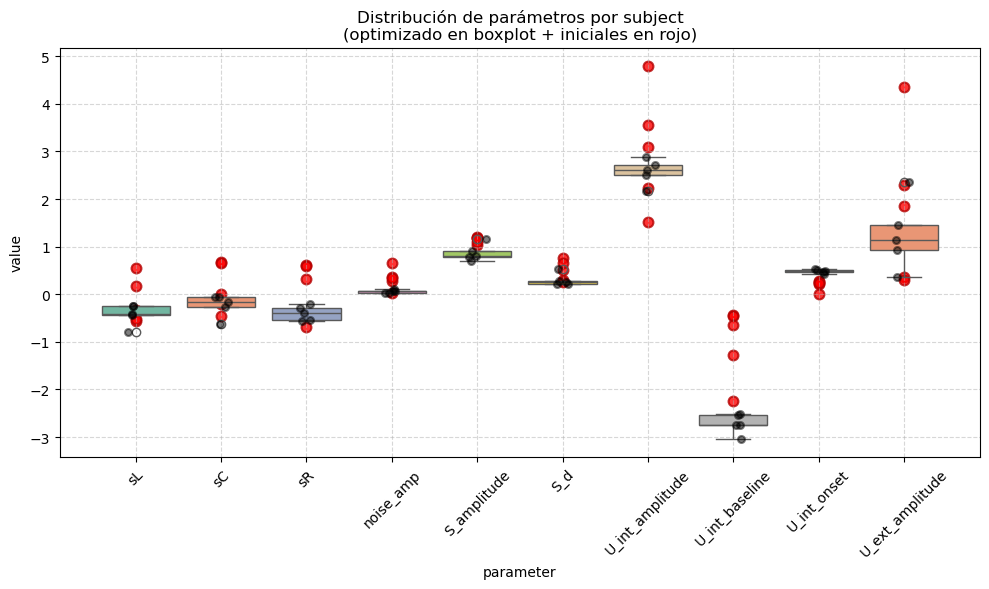

In [95]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from fitting_numba_full import objective_function

params_folder = 'params_result'

param_names = [
    'sL', 'sC', 'sR', 'noise_amp', 'S_amplitude', 'S_d',
    'U_int_amplitude', 'U_int_baseline', 'U_int_onset', 'U_ext_amplitude'
]

# ————————————————————————
# 1) Carga de resultados optimizados (result_*.pkl)
# ————————————————————————
opt_rows = []
opt_dict = {}   # para acceder luego a .x por sujeto
for filename in os.listdir(params_folder):
    if filename.startswith('result_') and filename.endswith('.pkl'):
        subject = filename.replace('result_', '').replace('.pkl', '')
        with open(os.path.join(params_folder, filename), 'rb') as f:
            res = pickle.load(f)
        # Sacamos .x
        if hasattr(res, 'x'):
            x_opt = np.array(res.x)
        elif isinstance(res, dict) and '.x' in res:
            x_opt = np.array(res['.x'])
        else:
            raise ValueError(f"No se encontró `.x` en {filename}")
        opt_dict[subject] = x_opt
        row = {'subject': subject}
        for name, val in zip(param_names, x_opt):
            row[name] = val
        opt_rows.append(row)

params_df = pd.DataFrame(opt_rows)
params_df = params_df.sort_values('subject').reset_index(drop=True)
df_melted = params_df.melt(id_vars='subject', var_name='parameter', value_name='value')

# ————————————————————————
# 2) Carga de los x0 (result2_*.pkl) y cálculo de diferencias
# ————————————————————————
init_dict = {}
for filename in os.listdir(params_folder):
    if filename.startswith('result2_') and filename.endswith('.pkl'):
        subject = filename.replace('result2_', '').replace('.pkl', '')
        with open(os.path.join(params_folder, filename), 'rb') as f:
            res2 = pickle.load(f)
        if hasattr(res2, 'x0'):
            x0 = np.array(res2.x0)
        elif isinstance(res2, dict) and 'x0' in res2:
            x0 = np.array(res2['x0'])
        else:
            raise ValueError(f"No se encontró `.x0` en {filename}")

        # Comprobar que existe un resultado optimizado
        if subject not in opt_dict:
            print(f"[Aviso] No hay resultado optimizado para sujeto {subject}; se omite.")
            continue

        x_opt = opt_dict[subject]
        diff = x_opt - x0

        init_dict[subject] = x0

        # Imprimir x0 y diferencias
        print(f"Subject: {subject}")
        print(f"  x0 : {x0}")
        print(f"  diff: {diff}\n")

# ————————————————————————
# 3) Ploteo: boxplot + puntos rojos de x0
# ————————————————————————
plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=df_melted, 
    x='parameter', 
    y='value', 
    palette='Set2'
)
sns.stripplot(
    data=df_melted, 
    x='parameter', 
    y='value', 
    color='black', 
    alpha=0.5, 
    jitter=True, 
    ax=ax
)

# Añadimos los puntos rojos para cada sujeto en result2_
# Asumimos que todos los vectores x0 tienen la misma longitud y orden que param_names
x_positions = np.arange(len(param_names))
for subj, x0 in init_dict.items():
    ax.scatter(
        x_positions, 
        x0, 
        color='red', 
        marker='o', 
        s=50, 
        alpha=0.8,
        label='_nolegend_'  # para que no duplique leyenda
    )

strip_darken(ax)
plt.title('Distribución de parámetros por subject\n(optimizado en boxplot + iniciales en rojo)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


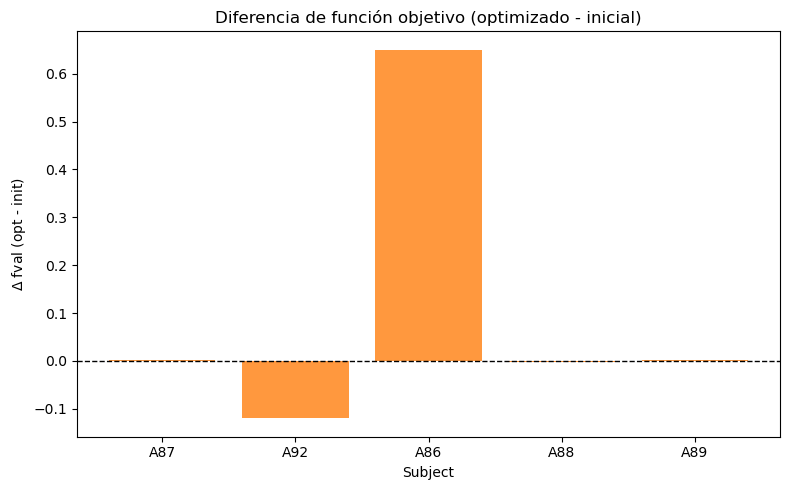

/var/folders/gk/r166p6nx2bb5zf2rlwww8fc00000gn/T/ipykernel_38496/1032362025.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.boxplot(


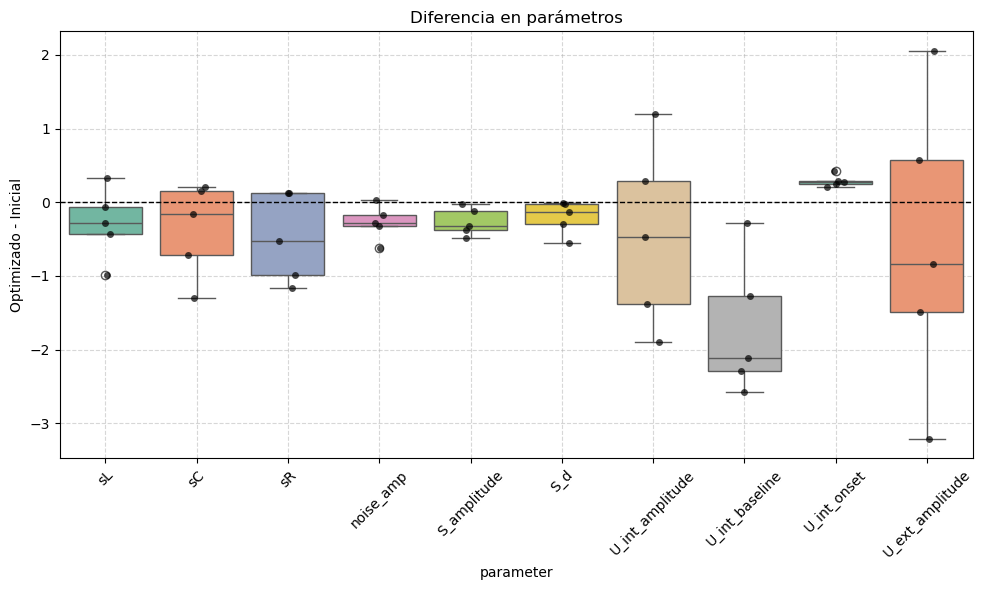

In [94]:
# ————————————————————————————————————————————————
# 4) Cálculo de diferencias de fval y coeficientes solo para sujetos con ambos archivos
# ————————————————————————————————————————————————

fval_diffs = []
coefs_diffs = []

for filename in os.listdir(params_folder):
    if filename.startswith('result2_') and filename.endswith('.pkl'):
        subject = filename.replace('result2_', '').replace('.pkl', '')
        path_opt = os.path.join(params_folder, f'result_{subject}.pkl')
        path_init = os.path.join(params_folder, f'result2_{subject}.pkl')

        if not os.path.exists(path_opt):
            print(f"[Aviso] Falta result_ para {subject}; se omite.")
            continue
        if not os.path.exists(path_init):
            print(f"[Aviso] Falta result2_ para {subject}; se omite.")
            continue

        # Carga fval optimizado
        with open(path_opt, 'rb') as f:
            res = pickle.load(f)
            fval_opt = float(res.fval)*100
        # Carga fval inicial
        with open(path_init, 'rb') as f:
            res2 = pickle.load(f)
            fval_init = float(res2.fval)*100

        fval_diffs.append({
            'subject': subject,
            'fval_optimized': fval_opt,
            'fval_init': fval_init,
            'delta_fval': fval_opt - fval_init
        })

        # Carga x0 y x_opt (ya tienes opt_dict y init_dict, pero lo hacemos robusto)
        if hasattr(res2, 'x0'):
            x0 = np.array(res2.x0)
        elif isinstance(res2, dict) and 'x0' in res2:
            x0 = np.array(res2['x0'])
        else:
            print(f"[Aviso] No se encontró x0 en {subject}.")
            continue

        if hasattr(res, 'x'):
            x_opt = np.array(res.x)
        elif isinstance(res, dict) and '.x' in res:
            x_opt = np.array(res['.x'])
        else:
            print(f"[Aviso] No se encontró x en {subject}.")
            continue

        # Si x0 es 2D (1 fila), aplánalo
        if isinstance(x0, np.ndarray) and x0.ndim == 2 and x0.shape[0] == 1:
            x0 = x0[0]
        if isinstance(x_opt, np.ndarray) and x_opt.ndim == 2 and x_opt.shape[0] == 1:
            x_opt = x_opt[0]

        if (len(x0) != len(param_names)) or (len(x_opt) != len(param_names)):
            print(f"[IGNORADO] {subject}: x0 ({len(x0)}), x_opt ({len(x_opt)}), param_names ({len(param_names)})")
            continue

        for i, pname in enumerate(param_names):
            coefs_diffs.append({
                'subject': subject,
                'parameter': pname,
                'diff': x_opt[i] - x0[i],
                'x_opt': x_opt[i],
                'x0': x0[i]
            })

# DataFrames para los plots
df_fval_diff = pd.DataFrame(fval_diffs)
df_coefs_diff = pd.DataFrame(coefs_diffs)

# ————————————————————————————————————————————————
# 5) Plot diferencias de fval (barplot)
# ————————————————————————————————————————————————

plt.figure(figsize=(8, 5))
plt.bar(df_fval_diff['subject'], df_fval_diff['delta_fval'], color='C1', alpha=0.8)
plt.axhline(0, color='k', linestyle='--', lw=1)
plt.xlabel('Subject')
plt.ylabel(r'$\Delta$ fval (opt - init)')
plt.title('Diferencia de función objetivo (optimizado - inicial)')
plt.tight_layout()
plt.show()

# ————————————————————————————————————————————————
# 6) Plot diferencias de parámetros (boxplot + stripplot)
# ————————————————————————————————————————————————

plt.figure(figsize=(10, 6))
ax2 = sns.boxplot(
    data=df_coefs_diff,
    x='parameter',
    y='diff',
    palette='Set2'
)
sns.stripplot(
    data=df_coefs_diff,
    x='parameter',
    y='diff',
    color='black',
    alpha=0.7,
    jitter=True,
    ax=ax2
)
plt.axhline(0, color='k', linestyle='--', lw=1)
plt.title('Diferencia en parámetros')
plt.ylabel('Optimizado - Inicial')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [9]:
def get_onset_offset(stim_dur, delay_dur, timepoint_1, timepoint_2, timepoint_3, timepoint_4):
    """
    Devuelve los posibles valores de onset y el valor de offset
    según el tipo de trial.
    """
    if stim_dur == 'VG':
        onset = 0
        offset = timepoint_4

    elif stim_dur == 'SS':
        if delay_dur == 'DS':
            onset = timepoint_2
            offset = timepoint_3
        elif delay_dur == 'DM':
            onset = timepoint_1
            offset = timepoint_2
        elif delay_dur == 'DL':
            onset = 0
            offset = timepoint_1

    elif stim_dur == 'SM':
        if delay_dur == 'DS':
            onset = timepoint_1
            offset = timepoint_3
        elif delay_dur == 'DM':
            onset = 0
            offset = timepoint_2

    elif stim_dur == 'SL':
        onset = 0
        offset = timepoint_3
    
    elif stim_dur == 'SIL':
        onset = 0
        offset = 0

    else:
        raise ValueError(f"stim_dur desconocido: {stim_dur}")

    return onset, offset


In [10]:
# Reimportamos tras el reset
import pandas as pd

# Simulación del DataFrame con los parámetros de un subject
subject_id = 'A86'
params_df = pd.read_csv(f'{params_folder}/params_df.csv')


In [11]:
from collections import defaultdict


df[['onset', 'offset']] = df.apply(
    lambda row: pd.Series(get_onset_offset(
        row['stimd_c'], row['ttype_c'],
        row['timepoint_1'], row['timepoint_2'],
        row['timepoint_3'], row['timepoint_4']
    )),
    axis=1
)


df['t4_bin'] = pd.qcut(df['timepoint_4'], 3, labels=['low', 'mid', 'high'])
df['onset_bin'] = pd.cut(df['onset'], bins=8)


subject_params = params_df[params_df['subject'] == 'A86'].iloc[0]
s_params = {'sL': subject_params.sL, 'sC': subject_params.sC, 'sR': subject_params.sR}
global_params = subject_params  # alias
N_SIM = 2000


predictions_by_bin = defaultdict(list)
accuracy_real = defaultdict(list)
bin_centers = defaultdict(list)

for t4_label in ['low', 'mid', 'high']:
    df_t4 = df[df['t4_bin'] == t4_label]
    for onset_bin, group in df_t4.groupby('onset_bin'):
        if len(group) < 5 or pd.isna(onset_bin): continue
        subset = group.sample(min(len(group), 20))  # trials representativos

        corrects = 0
        stim_onsets = []
        for _, row in subset.iterrows():
            side = row['x_c'] if row['ttype_c'] != 'SIL' else 'SIL'
            onset, offset = row['onset'], row['offset']
            Tmax = row['timepoint_4']

            S_params = {
                'offset': offset,
                'onset': onset,
                'd': global_params['S_d'],
                'amplitude': global_params['S_amplitude'],
            }
            U_int_params = {
                'offset': Tmax,
                'amplitude': global_params['U_int_amplitude'],
                'baseline': global_params['U_int_baseline'],
                'onset': global_params['U_int_onset'],
            }
            U_ext_params = {
                'offset': Tmax,
                'onset': onset,
                'amplitude': global_params['U_ext_amplitude'],
            }

            for _ in range(N_SIM // len(subset)):
                sim = run_trial_numba(
                    side=side,
                    S_params=S_params,
                    U_int_params=U_int_params,
                    U_ext_params=U_ext_params,
                    s_params=s_params,
                    Tmax=Tmax,
                    dt=0.1 / 40,
                    noise_amp=global_params['noise_amp']
                )
                if sim == row['r_c']:
                    corrects += 1
            stim_onsets.append(onset)

        predictions_by_bin[t4_label].append(corrects / N_SIM)
        accuracy_real[t4_label].append(group['correct_bool'].mean())
        bin_centers[t4_label].append(np.mean(stim_onsets))

/var/folders/gk/r166p6nx2bb5zf2rlwww8fc00000gn/T/ipykernel_61224/4126572568.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for onset_bin, group in df_t4.groupby('onset_bin'):
/var/folders/gk/r166p6nx2bb5zf2rlwww8fc00000gn/T/ipykernel_61224/4126572568.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for onset_bin, group in df_t4.groupby('onset_bin'):
/var/folders/gk/r166p6nx2bb5zf2rlwww8fc00000gn/T/ipykernel_61224/4126572568.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or obs

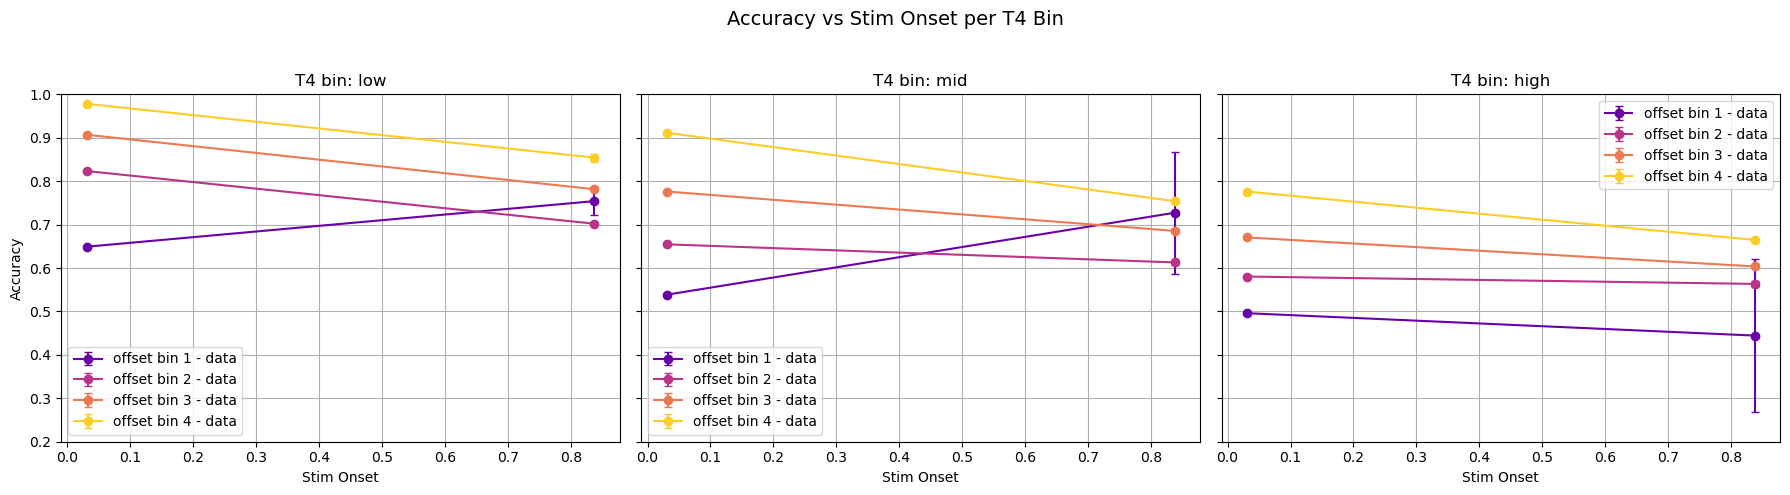

Offset bins (ordered):
  Bin 1: (0.015099999999999999, 0.767]
  Bin 2: (0.767, 1.078]
  Bin 3: (1.078, 1.438]
  Bin 4: (1.438, 29.841]

Onset bins (ordered):
  Bin 1: (-0.001, 0.509]
  Bin 2: (0.509, 2.676]

Onset bin centers:
  Bin 1: 0.0307
  Bin 2: 0.8373
T4 bin edges:
  low: 0.6950 — 2.5843
  mid: 2.5843 — 3.4623
  high: 3.4623 — 1674.8061


In [45]:
import numpy as np
import matplotlib.pyplot as plt

df_nonsil = df[df['ttype_c'] != 'SIL'].copy()
n_bins_onset = 5
n_bins_offset = 4

df_nonsil['t4_bin'], edges = pd.qcut(df_nonsil['timepoint_4'], 3, labels=['low', 'mid', 'high'], retbins=True)
# Paso 1: Definir offset_bin y onset_bin sobre TODO el df
df_nonsil['offset_bin'] = pd.qcut(df_nonsil['offset'], n_bins_offset, duplicates='drop')
df_nonsil['onset_bin'] = pd.qcut(df_nonsil['onset'], n_bins_onset, duplicates='drop')
offset_bins_ordered = df_nonsil['offset_bin'].cat.categories
onset_bins_ordered = df_nonsil['onset_bin'].cat.categories

# Centros de los onset bins para eje X
onset_bin_centers = []
for onset_bin in onset_bins_ordered:
    subset = df_nonsil[df_nonsil['onset_bin'] == onset_bin]
    if not subset.empty:
        onset_bin_centers.append(subset['onset'].mean())
    else:
        onset_bin_centers.append(np.nan)

# --- PLOT ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
colors = plt.cm.plasma(np.linspace(0.2, 0.9, n_bins_offset))

for i, t4_bin in enumerate(['low', 'mid', 'high']):
    ax = axes[i]
    df_t4 = df_nonsil[df_nonsil['t4_bin'] == t4_bin].copy()

    for j, offset_bin in enumerate(offset_bins_ordered):
        acc_real = []
        sem_real = []
        for onset_bin in onset_bins_ordered:
            df_bin = df_t4[(df_t4['offset_bin'] == offset_bin) & (df_t4['onset_bin'] == onset_bin)]
            # --- Filtro crítico: offset > onset ---
            df_bin = df_bin[df_bin['offset'] > df_bin['onset']]
            if len(df_bin) == 0:
                acc_real.append(np.nan)
                sem_real.append(np.nan)
            else:
                acc_real.append(df_bin['correct_bool'].mean())
                sem_real.append(df_bin['correct_bool'].std() / np.sqrt(len(df_bin)))

        label = f'offset bin {j+1}'
        ax.errorbar(
            onset_bin_centers, acc_real, yerr=sem_real,
            fmt='o-', label=f'{label} - data', color=colors[j], capsize=3
        )

    ax.set_title(f'T4 bin: {t4_bin}')
    ax.set_xlabel('Stim Onset')
    if i == 0:
        ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True)
    ax.set_ylim(0.2, 1)

plt.suptitle('Accuracy vs Stim Onset per T4 Bin', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Print the ordered bins
print("Offset bins (ordered):")
for i, bin_range in enumerate(offset_bins_ordered):
    print(f"  Bin {i+1}: {bin_range}")

print("\nOnset bins (ordered):")
for i, bin_range in enumerate(onset_bins_ordered):
    print(f"  Bin {i+1}: {bin_range}")

# Print onset bin centers for reference
print("\nOnset bin centers:")
for i, center in enumerate(onset_bin_centers):
    print(f"  Bin {i+1}: {center:.4f}")
    
labels = ['low', 'mid', 'high']
print("T4 bin edges:")
for i in range(len(edges)-1):
    print(f"  {labels[i]}: {edges[i]:.4f} — {edges[i+1]:.4f}")



In [73]:
import numpy as np
import pandas as pd

# Asume que ya tienes df_nonsil y t4_labels definidos
n_bins_onset = 5
n_bins_offset = 4

for t4 in t4_labels:
    df_t4 = df_nonsil[df_nonsil['t4_bin'] == t4].copy()
    # Offset bins por cuantiles (igual que en el plot)
    df_t4['offset_bin'], offset_edges = pd.qcut(
        df_t4['offset'],
        q=n_bins_offset,
        duplicates='drop',
        retbins=True
    )
    offset_bins = df_t4['offset_bin'].cat.categories

    # Onset en bins uniformes (igual que en el plot)
    onset_min, onset_max = df_t4['onset'].min(), df_t4['onset'].max()
    onset_edges = np.linspace(onset_min, onset_max, n_bins_onset+1)
    df_t4['onset_bin'] = pd.qcut(
        df_t4['onset'],
        bins=onset_edges,
        include_lowest=True
    )
    onset_bins = df_t4['onset_bin'].cat.categories
    onset_centers = (onset_edges[:-1] + onset_edges[1:]) / 2

    print(f"\nT4 bin = '{t4}'")
    print("Offset edges:", np.round(offset_edges,4))
    print("Onset edges: ", np.round(onset_edges,4))

    # Conteo de trials usados en cada punto
    rows = []
    for j, ob in enumerate(offset_bins):
        for k, obin in enumerate(onset_bins):
            sub = df_t4[
                (df_t4['offset_bin'] == ob) &
                (df_t4['onset_bin']  == obin) &
                (df_t4['offset']     > df_t4['onset'])
            ]
            rows.append({
                'offset_bin':   f"{j+1}",
                'onset_bin':    f"{k+1}",
                'onset_center': onset_centers[k],
                'n_trials':     len(sub)
            })
    counts_df = pd.DataFrame(rows)
    print(counts_df.pivot(index='onset_bin', columns='offset_bin', values='n_trials'))


TypeError: qcut() got an unexpected keyword argument 'bins'

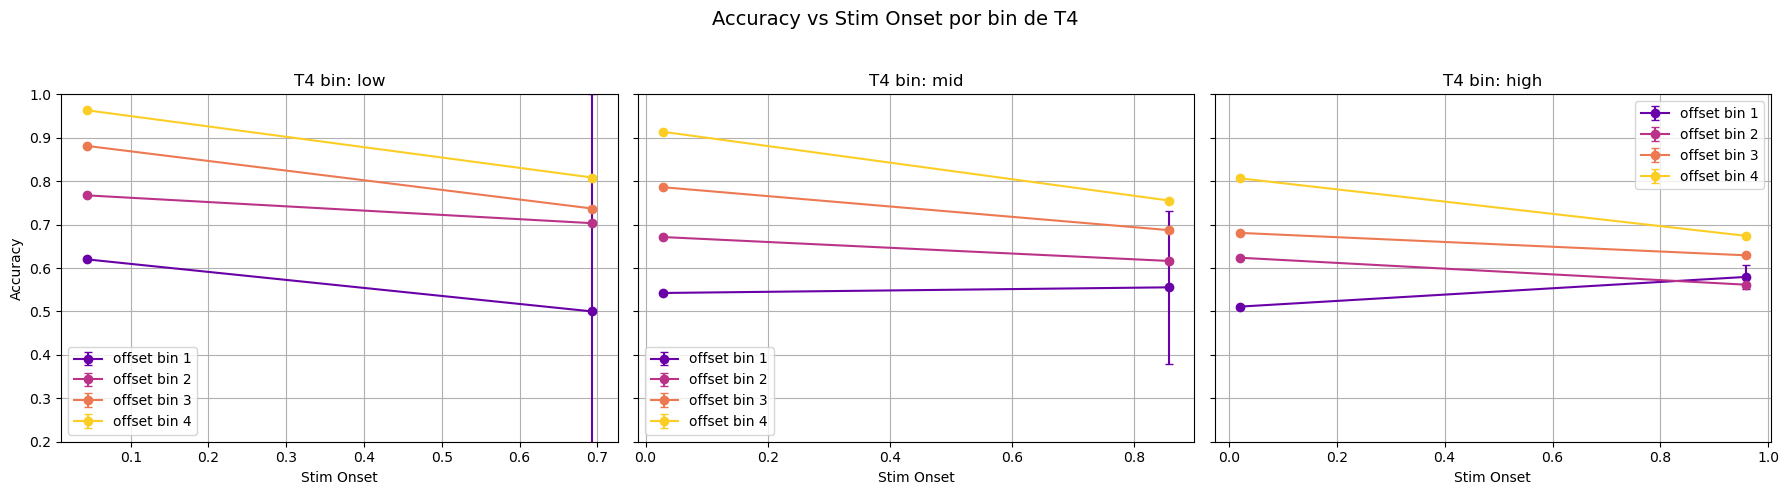

T4 bin edges: [6.94999933e-01 2.58430004e+00 3.46230006e+00 1.67480610e+03]


In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Filtramos sólo trials no-SIL
df_nonsil = df[df['ttype_c'] != 'SIL'].copy()

# Parámetros de binning
n_bins_onset = 5
n_bins_offset = 4
t4_labels = ['low', 'mid', 'high']

# Creamos figura
fig, axes = plt.subplots(1, len(t4_labels), figsize=(18, 5), sharey=True)
colors = plt.cm.plasma(np.linspace(0.2, 0.9, n_bins_offset))

# Binning global para timepoint_4 (sólo para asignar etiquetas)
df_nonsil['t4_bin'], t4_edges = pd.qcut(
    df_nonsil['timepoint_4'],
    q=3,
    labels=t4_labels,
    retbins=True
)

for i, t4 in enumerate(t4_labels):
    ax = axes[i]
    df_t4 = df_nonsil[df_nonsil['t4_bin'] == t4].copy()

    # 1) Rehacer el binning DENTRO de este t4-subgrupo
    df_t4['offset_bin'] = pd.qcut(
        df_t4['offset'],
        q=n_bins_offset,
        duplicates='drop'
    )
    df_t4['onset_bin'] = pd.qcut(
        df_t4['onset'],
        q=n_bins_onset,
        duplicates='drop'
    )

    offset_bins = df_t4['offset_bin'].cat.categories
    onset_bins  = df_t4['onset_bin'].cat.categories

    # Centros de cada onset_bin (para el eje X)
    onset_centers = [
        df_t4.loc[df_t4['onset_bin'] == b, 'onset'].mean()
        for b in onset_bins
    ]

    # 2) Para cada bin de offset, calculamos media y SEM en cada bin de onset
    for j, ob in enumerate(offset_bins):
        acc_real = []
        sem_real = []
        for on_b in onset_bins:
            sub = df_t4[
                (df_t4['offset_bin'] == ob) &
                (df_t4['onset_bin']  == on_b)
            ]
            # aplicamos el filtro crítico
            if len(sub) > 0:
                acc_real.append(sub['correct_bool'].mean())
                sem_real.append(sub['correct_bool'].std() / np.sqrt(len(sub)))
            else:
                acc_real.append(np.nan)
                sem_real.append(np.nan)

        ax.errorbar(
            onset_centers,
            acc_real,
            yerr=sem_real,
            fmt='o-',
            label=f'offset bin {j+1}',
            color=colors[j],
            capsize=3
        )

    ax.set_title(f'T4 bin: {t4}')
    ax.set_xlabel('Stim Onset')
    if i == 0:
        ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True)
    ax.set_ylim(0.2, 1.0)

plt.suptitle('Accuracy vs Stim Onset por bin de T4', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# (Opcional) Mostrar los edges de T4 para referencia
print("T4 bin edges:", t4_edges)


In [ ]:
for i, t4 in enumerate(t4_labels):
    df_t4 = df_nonsil[df_nonsil['t4_bin'] == t4].copy()

    # Rehacemos los qcut y obtenemos edges
    df_t4['offset_bin'], offset_edges = pd.qcut(
        df_t4['offset'],
        q=n_bins_offset,
        duplicates='drop',
        retbins=True
    )
    df_t4['onset_bin'], onset_edges = pd.qcut(
        df_t4['onset'],
        q=3,
        duplicates='drop',
        retbins=True
    )

    print(f"T4 = '{t4}'")
    print("  Offset edges:", np.round(offset_edges, 4))
    print("  Onset  edges:", np.round(onset_edges, 4))
    print()

    # …resto del plotting…


T4 = 'low'
  Offset edges: [0.1112 0.6457 0.9292 1.2005 2.5843]
  Onset  edges: [0.     0.4859 0.6445 1.4622]

T4 = 'mid'
  Offset edges: [0.0161 0.7974 1.1228 1.4542 3.4623]
  Onset  edges: [0.     0.5436 0.8019 2.0742]

T4 = 'high'
  Offset edges: [ 0.0382  0.8785  1.2143  1.6221 29.8407]
  Onset  edges: [0.     0.5222 0.8744 2.6761]



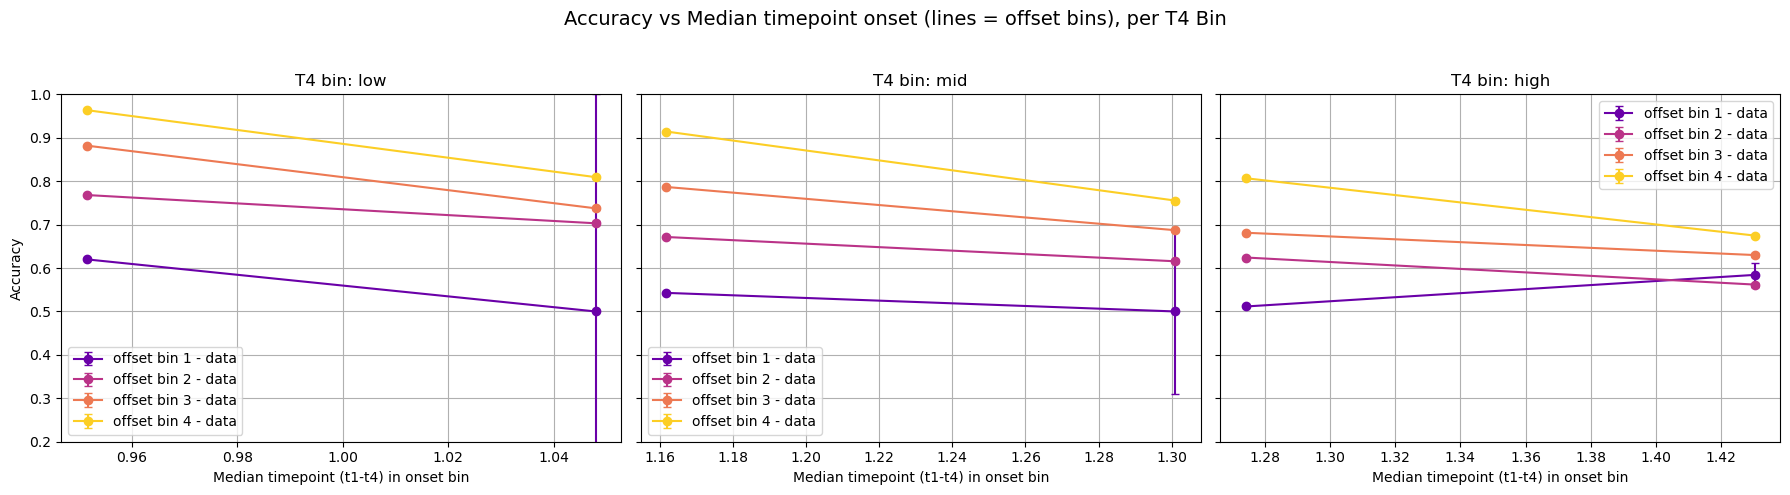

In [35]:
import numpy as np
import matplotlib.pyplot as plt

df_nonsil = df[df['ttype_c'] != 'SIL'].copy()
n_bins_onset = 5
n_bins_offset = 4

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
t4_labels = ['low', 'mid', 'high']
colors = plt.cm.plasma(np.linspace(0.2, 0.9, n_bins_offset))

for i, t4_bin in enumerate(t4_labels):
    ax = axes[i]
    df_t4 = df_nonsil[df_nonsil['t4_bin'] == t4_bin].copy()
    # Si hay pocos trials únicos, el número de bins puede bajar
    df_t4['offset_bin'] = pd.qcut(df_t4['offset'], n_bins_offset, duplicates='drop')
    df_t4['onset_bin']  = pd.qcut(df_t4['onset'], n_bins_onset,  duplicates='drop')
    offset_bins_ordered = df_t4['offset_bin'].cat.categories
    onset_bins_ordered  = df_t4['onset_bin'].cat.categories

    # Mediana de t1-t4 para centro de onset_bin (por panel)
    onset_bin_centers = []
    for onset_bin in onset_bins_ordered:
        subset = df_t4[df_t4['onset_bin'] == onset_bin]
        if not subset.empty:
            # Mediana conjunta de todos los t1-4 de los trials en el bin
            median_t = np.median(subset[['timepoint_1', 'timepoint_2', 'timepoint_3', 'timepoint_4']].values)
            onset_bin_centers.append(median_t)
        else:
            onset_bin_centers.append(np.nan)

    for j, offset_bin in enumerate(offset_bins_ordered):
        acc_real = []
        sem_real = []
        for onset_bin in onset_bins_ordered:
            df_bin = df_t4[(df_t4['offset_bin'] == offset_bin) & (df_t4['onset_bin'] == onset_bin)]
            df_bin = df_bin[df_bin['offset'] > df_bin['onset']]
            if len(df_bin) == 0:
                acc_real.append(np.nan)
                sem_real.append(np.nan)
            else:
                acc_real.append(df_bin['correct_bool'].mean())
                sem_real.append(df_bin['correct_bool'].std() / np.sqrt(len(df_bin)))

        label = f'offset bin {j+1}'
        ax.errorbar(
            onset_bin_centers, acc_real, yerr=sem_real,
            fmt='o-', label=f'{label} - data', color=colors[j], capsize=3
        )

    ax.set_title(f'T4 bin: {t4_bin}')
    ax.set_xlabel('Median timepoint (t1-t4) in onset bin')
    if i == 0:
        ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True)
    ax.set_ylim(0.2, 1)

plt.suptitle('Accuracy vs Median timepoint onset (lines = offset bins), per T4 Bin', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



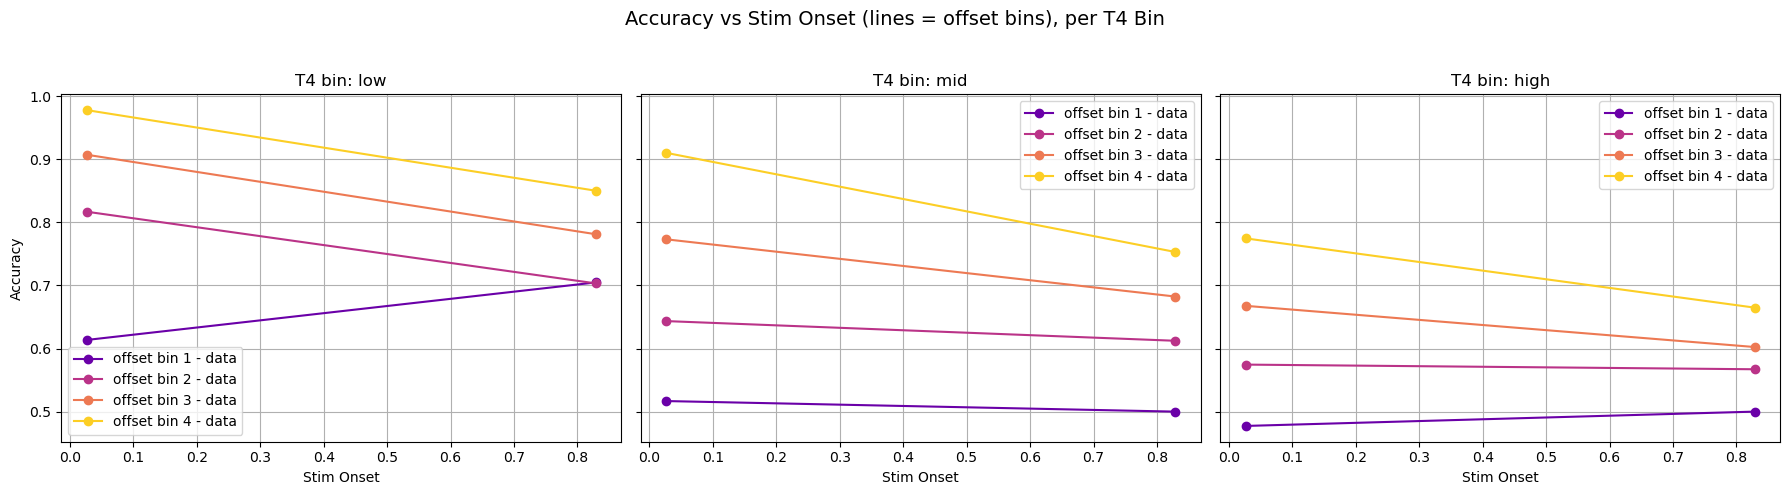

In [36]:
# Paso 1: Definir offset_bin y onset_bin sobre TODO el df
df['offset_bin'] = pd.qcut(df['offset'], n_bins_offset, duplicates='drop')
df['onset_bin'] = pd.qcut(df['onset'], n_bins_onset, duplicates='drop')
offset_bins_ordered = df['offset_bin'].cat.categories
onset_bins_ordered = df['onset_bin'].cat.categories

# Opcional: calcular centros de los onset bins para eje X
onset_bin_centers = []
for onset_bin in onset_bins_ordered:
    subset = df[df['onset_bin'] == onset_bin]
    if not subset.empty:
        onset_bin_centers.append(subset['onset'].mean())
    else:
        onset_bin_centers.append(np.nan)

# --- PLOT ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
colors = plt.cm.plasma(np.linspace(0.2, 0.9, n_bins_offset))

for i, t4_bin in enumerate(['low', 'mid', 'high']):
    ax = axes[i]
    df_t4 = df[df['t4_bin'] == t4_bin].copy()

    for j, offset_bin in enumerate(offset_bins_ordered):
        acc_real = []
        for onset_bin in onset_bins_ordered:
            df_bin = df_t4[(df_t4['offset_bin'] == offset_bin) & (df_t4['onset_bin'] == onset_bin)]
            if len(df_bin) == 0:
                acc_real.append(np.nan)
            else:
                acc_real.append(df_bin['correct_bool'].mean())

        label = f'offset bin {j+1}'
        ax.plot(onset_bin_centers, acc_real, marker='o', label=f'{label} - data', color=colors[j])

    ax.set_title(f'T4 bin: {t4_bin}')
    ax.set_xlabel('Stim Onset')
    if i == 0:
        ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True)

plt.suptitle('Accuracy vs Stim Onset (lines = offset bins), per T4 Bin', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

/var/folders/gk/r166p6nx2bb5zf2rlwww8fc00000gn/T/ipykernel_38496/2889551996.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df_sil.groupby('t4_bin_fino')['correct_bool'].agg(['mean', 'count', 'std']).reset_index()


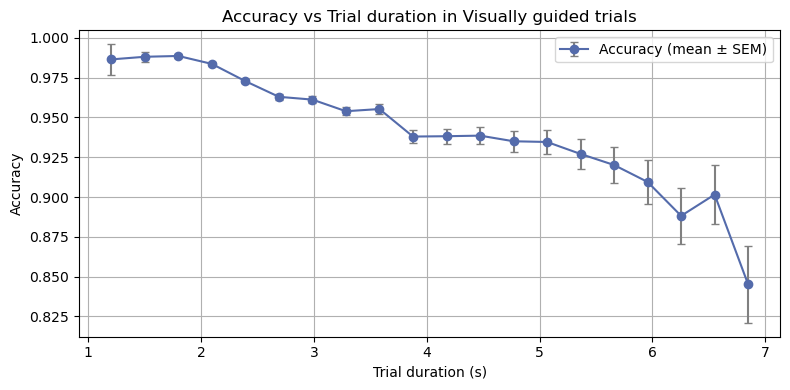

In [97]:
import numpy as np
import matplotlib.pyplot as plt

# Filtramos solo SIL
df_sil = df[df['ttype_c'] == 'VG'].copy()

# Número de bins finos (ajusta a tu gusto)
n_bins_fino = 20

# Binning de t4
df_sil = df_sil[df_sil['timepoint_4']<=7]
df_sil['t4_bin_fino'] = pd.cut(df_sil['timepoint_4'], bins=n_bins_fino)
# Calculamos la media y el error estándar de la media (SEM) en cada bin
summary = df_sil.groupby('t4_bin_fino')['correct_bool'].agg(['mean', 'count', 'std']).reset_index()
summary['sem'] = summary['std'] / np.sqrt(summary['count'])

# Centro de cada bin para el eje X
summary['t4_bin_center'] = summary['t4_bin_fino'].apply(lambda x: x.mid)

plt.figure(figsize=(8,4))
plt.errorbar(summary['t4_bin_center'], summary['mean'], yerr=summary['sem'], 
             fmt='o-', color='#546bab', ecolor='gray', capsize=3, label='Accuracy (mean ± SEM)')
plt.xlabel('Trial duration (s)')
plt.ylabel('Accuracy')
plt.title(f'Accuracy vs Trial duration in Visually guided trials')
# plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()



ValueError: missing values must be missing in the same location both left and right sides

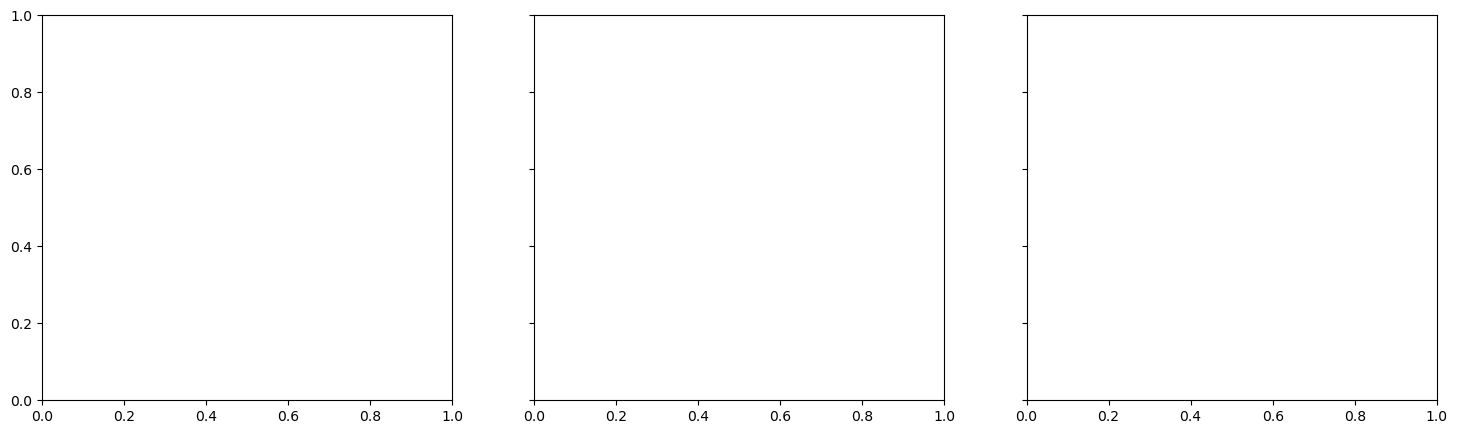

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df_nonsil = df[df['ttype_c'] != 'SIL'].copy()
n_bins_onset = 5   # bins no nulos (además del de onset=0)
n_bins_offset = 4

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
t4_labels = ['low', 'mid', 'high']
colors = plt.cm.plasma(np.linspace(0.2, 0.9, n_bins_offset))

for i, t4_bin in enumerate(t4_labels):
    ax = axes[i]
    df_t4 = df_nonsil[df_nonsil['t4_bin'] == t4_bin].copy()

    # Separamos los trials con onset=0
    df_onset0 = df_t4[df_t4['onset'] == 0].copy()
    df_rest   = df_t4[df_t4['onset'] > 0].copy()

    # Hacemos binning de onset solo sobre los que no son 0
    if len(df_rest) > 0:
        t_all = np.concatenate([
            df_rest['timepoint_1'].values,
            df_rest['timepoint_2'].values,
            df_rest['timepoint_3'].values,
            df_rest['timepoint_4'].values,
        ])
        n_bins_onset_eff = min(n_bins_onset, len(np.unique(t_all)))
        onset_bins = pd.qcut(t_all, n_bins_onset_eff, retbins=True, duplicates='drop')[1]
        # Asegurarse que el borde izquierdo es >0 (para no "pisar" el 0)
        onset_bins[0] = np.nextafter(0, 1)
        df_rest['onset_bin'] = pd.cut(df_rest['onset'], bins=onset_bins, include_lowest=True)
    else:
        df_rest['onset_bin'] = pd.Series(dtype='category')

    # Para onset=0 ponemos una categoría especial
    df_onset0['onset_bin'] = 'onset=0'

    # Juntamos de nuevo
    df_t4 = pd.concat([df_onset0, df_rest], axis=0)
    # Hacemos binning de offset normalmente
    t_all_offset = np.concatenate([
        df_t4['timepoint_1'].values,
        df_t4['timepoint_2'].values,
        df_t4['timepoint_3'].values,
        df_t4['timepoint_4'].values,
    ])
    n_bins_offset_eff = min(n_bins_offset, len(np.unique(t_all_offset)))
    offset_bins = pd.qcut(t_all_offset, n_bins_offset_eff, retbins=True, duplicates='drop')[1]
    df_t4['offset_bin'] = pd.cut(df_t4['offset'], bins=offset_bins, include_lowest=True)

    # Definir el orden de onset_bin: primero onset=0, luego los numéricos en orden
    onset_bins_ordered = ['onset=0'] + [str(c) for c in df_rest['onset_bin'].cat.categories]
    offset_bins_ordered = df_t4['offset_bin'].cat.categories

    # Centros de los onset bins: onset=0 es simplemente 0, el resto como antes
    onset_bin_centers = [0.0]  # para onset=0
    for onset_bin in df_rest['onset_bin'].cat.categories:
        subset = df_rest[df_rest['onset_bin'] == onset_bin]
        if not subset.empty:
            all_times = np.concatenate([
                subset['timepoint_1'].values,
                subset['timepoint_2'].values,
                subset['timepoint_3'].values,
                subset['timepoint_4'].values,
            ])
            onset_bin_centers.append(np.median(all_times))
        else:
            onset_bin_centers.append(np.nan)

    for j, offset_bin in enumerate(offset_bins_ordered):
        acc_real = []
        sem_real = []
        for k, onset_bin in enumerate(onset_bins_ordered):
            if onset_bin == 'onset=0':
                df_bin = df_t4[df_t4['onset_bin'] == onset_bin]
            else:
                df_bin = df_t4[df_t4['onset_bin'] == onset_bin]
            df_bin = df_bin[df_bin['offset'] > df_bin['onset']]
            if len(df_bin) == 0:
                acc_real.append(np.nan)
                sem_real.append(np.nan)
            else:
                acc_real.append(df_bin['correct_bool'].mean())
                sem_real.append(df_bin['correct_bool'].std() / np.sqrt(len(df_bin)))
        # Opcional: sólo líneas con al menos 2 puntos válidos
        if np.sum(~np.isnan(acc_real)) < 2:
            continue
        label = f'offset bin {j+1}'
        ax.errorbar(
            onset_bin_centers, acc_real, yerr=sem_real,
            fmt='o-', label=f'{label} - data', color=colors[j], capsize=3
        )

    ax.set_title(f'T4 bin: {t4_bin}')
    ax.set_xlabel('Median t1-t4 (all trials in onset bin)')
    if i == 0:
        ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True)
    ax.set_ylim(0.2, 1)

plt.suptitle('Accuracy vs Median t1-t4 (lines = offset bins, onset=0 separate), per T4 Bin', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


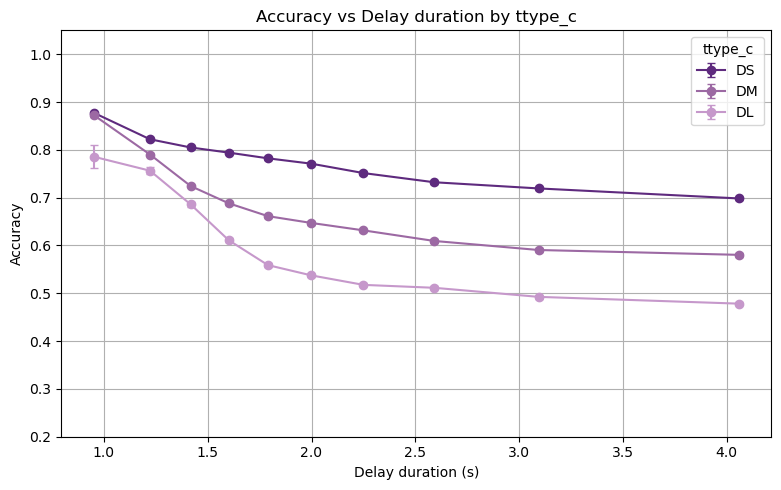

Delay duration bin edges:
  Bin 1: 0.056 — 1.112
  Bin 2: 1.112 — 1.324
  Bin 3: 1.324 — 1.510
  Bin 4: 1.510 — 1.693
  Bin 5: 1.693 — 1.889
  Bin 6: 1.889 — 2.115
  Bin 7: 2.115 — 2.400
  Bin 8: 2.400 — 2.804
  Bin 9: 2.804 — 3.446
  Bin 10: 3.446 — 5.000


In [44]:
df['delay_duration'] = df['timepoint_4'] - df['offset']
df_nonsil = df[(df['ttype_c'] != 'SIL') & (df['ttype_c'] != 'VG')].copy()
df_nonsil = df_nonsil[df_nonsil['delay_duration'] <5].copy()
# Define parámetros de binning
n_bins = 10

# Binning con pd.qcut
df_nonsil['delay_bin'], delay_edges = pd.qcut(df_nonsil['delay_duration'], n_bins, retbins=True, duplicates='drop')
delay_bin_centers = []
for b in df_nonsil['delay_bin'].cat.categories:
    # Centro del bin = media de los delay_duration en ese bin
    subset = df_nonsil[df_nonsil['delay_bin'] == b]
    if not subset.empty:
        delay_bin_centers.append(subset['delay_duration'].mean())
    else:
        delay_bin_centers.append(np.nan)

ttype_colors = {'DS':'#2980B9', 'DM':'#27AE60', 'DL':'#E67E22'}
ttype_colors = {
    # '#230027',  # Darkest Purple
    'DS': '#5E2A7E',  # Dark Purple
    'DM': '#9C69A3',  # Medium Purple
    'DL':'#C698CB',  # Light Purple
    # '#EFD9F5'   # Lightest Purple
}
plt.figure(figsize=(8, 5))

for ttype, color in ttype_colors.items():
    df_type = df_nonsil[df_nonsil['ttype_c'] == ttype]
    means = []
    sems = []
    for cat in df_nonsil['delay_bin'].cat.categories:
        bin_trials = df_type[df_type['delay_bin'] == cat]
        if len(bin_trials) > 0:
            means.append(bin_trials['correct_bool'].mean())
            sems.append(bin_trials['correct_bool'].std() / np.sqrt(len(bin_trials)))
        else:
            means.append(np.nan)
            sems.append(np.nan)
    plt.errorbar(delay_bin_centers, means, yerr=sems, fmt='o-', color=color, capsize=3, label=ttype)

plt.xlabel('Delay duration (s)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Delay duration by ttype_c')
plt.legend(title='ttype_c')
plt.grid(True)
plt.tight_layout()
plt.ylim(0.2, 1.05)
plt.show()

# (Opcional) Imprime los bordes de los bins de delay
print("Delay duration bin edges:")
for i in range(len(delay_edges)-1):
    print(f"  Bin {i+1}: {delay_edges[i]:.3f} — {delay_edges[i+1]:.3f}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

subject = 'A86'
df_subj = df_nonsil[df_nonsil['subject'] == subject].copy()
params_row = params_df[params_df['subject'] == subject].iloc[0]
params_row = params_df[params_df['subject'] == 'A86_new_b'].iloc[0]
global_params = params_row.to_dict()
display(global_params)
n_bins = 8
n_sim = 1000

# Binning igual que antes
df_subj['delay_bin'], delay_edges = pd.qcut(df_subj['delay_duration'], n_bins, retbins=True, duplicates='drop')
delay_bin_centers = []
for b in df_subj['delay_bin'].cat.categories:
    subset = df_subj[df_subj['delay_bin'] == b]
    delay_bin_centers.append(subset['delay_duration'].mean() if not subset.empty else np.nan)

ttype_colors = {'DS':'#2980B9', 'DM':'#27AE60', 'DL':'#E67E22'}

plt.figure(figsize=(8, 5))

for ttype, color in ttype_colors.items():
    means_real = []
    sems_real = []
    acc_simulated = []
    for i, cat in enumerate(df_subj['delay_bin'].cat.categories):
        bin_trials = df_subj[(df_subj['delay_bin'] == cat) & (df_subj['ttype_c'] == ttype)]
        if len(bin_trials) > 0:
            # Datos reales
            means_real.append(bin_trials['correct_bool'].mean())
            sems_real.append(bin_trials['correct_bool'].std() / np.sqrt(len(bin_trials)))
            # Valores representativos para simulación en ese bin/ttype
            onset   = bin_trials['onset'].mean()
            offset  = bin_trials['offset'].mean()
            Tmax    = bin_trials['timepoint_4'].mean()
            # Determine side based on bin_trials - most common r_c value or random if empty
            

            S_params = {
                'offset': offset,
                'onset': onset,
                'd': global_params['S_d'],
                'amplitude': global_params['S_amplitude'],
            }
            U_int_params = {
                'offset': Tmax,
                'amplitude': global_params['U_int_amplitude'],
                'baseline': global_params['U_int_baseline'],
                'onset': global_params['U_int_onset'],
            }
            U_ext_params = {
                'offset': Tmax,
                'onset': onset,
                'amplitude':0,
            }
            s_params = {
                'sL': global_params['sL'],
                'sC': global_params['sC'],
                'sR': global_params['sR'],
            }
            # s_params = {'sL': 0, 'sC': 0, 'sR': 0} 
            correct_count = 0
            for _ in range(n_sim):
                side =  np.random.choice(['L', 'C', 'R'])
                sim = run_trial_numba(
                    side=side,
                    S_params=S_params,
                    U_int_params=U_int_params,
                    U_ext_params=U_ext_params,
                    s_params=s_params,
                    Tmax=Tmax,
                    dt=0.1/40,
                    noise_amp= global_params['noise_amp']
                )
                if sim == side:
                    correct_count += 1
                # print(f"Simulated trial {i+1}/{n_sim} for ttype '{ttype}' in delay bin '{cat}': {sim} (correct: {side})")
            print(f"Simulated {n_sim} trials for ttype '{ttype}' in delay bin '{cat}': {correct_count} correct")
            acc_simulated.append(correct_count / n_sim)
        else:
            means_real.append(np.nan)
            sems_real.append(np.nan)
            acc_simulated.append(np.nan)

    # Plotea datos reales
    plt.errorbar(delay_bin_centers, means_real, yerr=sems_real, fmt='o-', color=color, capsize=3, label=f'{ttype} (real)')
    # Plotea simulación modelo
    plt.plot(delay_bin_centers, acc_simulated, '--o', color=color, alpha=0.7, label=f'{ttype} (modelo)')

plt.xlabel('Delay duration (s)')
plt.ylabel('Accuracy')
plt.title(f'Accuracy vs Delay duration (subject {subject})')
plt.legend(title='ttype_c')
plt.grid(True)
plt.tight_layout()
plt.show()


NameError: name 'df_nonsil' is not defined

In [146]:
S_params = {
    'offset': 0,
    'onset': 1,
    'd': 0.21229928769427317,
    'amplitude': 1.1683909805474229,
}
U_int_params = {
    'offset': Tmax,
    'amplitude': 2.175688427505179,
    'baseline': -2.522758254990009,
    'onset': 0.5172393150793442,
}
U_ext_params = {
    'offset': 2.1,
    'onset': 0,
    'amplitude': 0,
}
s_params = {
    'sL': -0.273228911452662,
    'sC': -0.060502582788387826,
    'sR': -0.1788309862,
}
side = 'R'  # Asumiendo que el lado es 'C' para este ejemplo
sim = run_trial_numba(
        side=side,
        S_params=S_params,
        U_int_params=U_int_params,
        U_ext_params=U_ext_params,
        s_params=s_params,
        Tmax=Tmax,
        dt=0.1/40,
        noise_amp= 0.10986768073436771
    )
print(f"side: {side}, result sim: {sim}")

side: R, result sim: C


In [147]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

subject = 'A92'
df_subj = df_nonsil[df_nonsil['subject'] == subject].copy()
params_row = params_df[params_df['subject'] == subject].iloc[0]
global_params = params_row.to_dict()
display(global_params)
n_bins = 8
n_sim = 10000

# Binning igual que antes
df_subj['delay_bin'], delay_edges = pd.qcut(df_subj['delay_duration'], n_bins, retbins=True, duplicates='drop')
delay_bin_centers = []
for b in df_subj['delay_bin'].cat.categories:
    subset = df_subj[df_subj['delay_bin'] == b]
    delay_bin_centers.append(subset['delay_duration'].mean() if not subset.empty else np.nan)

ttype_colors = {'DS':'#2980B9', 'DM':'#27AE60', 'DL':'#E67E22'}

plt.figure(figsize=(8, 5))

for ttype, color in ttype_colors.items():
    means_real = []
    sems_real = []
    acc_simulated = []
    for i, cat in enumerate(df_subj['delay_bin'].cat.categories):
        bin_trials = df_subj[(df_subj['delay_bin'] == cat) & (df_subj['ttype_c'] == ttype)]
        if len(bin_trials) > 0:
            # Datos reales
            means_real.append(bin_trials['correct_bool'].mean())
            sems_real.append(bin_trials['correct_bool'].std() / np.sqrt(len(bin_trials)))
            # Valores representativos para simulación en ese bin/ttype
            onset   = bin_trials['onset'].mean()
            offset  = bin_trials['offset'].mean()
            Tmax    = bin_trials['timepoint_4'].mean()
            # Determine side based on bin_trials - most common r_c value or random if empty
            side =  np.random.choice(['L', 'C', 'R'])

            S_params = {
                'offset': offset,
                'onset': onset,
                'd': global_params['S_d'],
                'amplitude': global_params['S_amplitude'],
            }
            U_int_params = {
                'offset': Tmax,
                'amplitude': global_params['U_int_amplitude'],
                'baseline': global_params['U_int_baseline'],
                'onset': global_params['U_int_onset'],
            }
            U_ext_params = {
                'offset': Tmax,
                'onset': onset,
                'amplitude': global_params['U_ext_amplitude'],
            }
            s_params = {
                'sL': global_params['sL'],
                'sC': global_params['sC'],
                'sR': global_params['sR'],
            }

            # Simulaciones para esa condición bin + ttype
            correct_count = 0
            for _ in range(n_sim):
                sim = run_trial_numba(
                    side=side,
                    S_params=S_params,
                    U_int_params=U_int_params,
                    U_ext_params=U_ext_params,
                    s_params=s_params,
                    Tmax=Tmax,
                    dt=0.1/40,
                    noise_amp= global_params['noise_amp']
                )
                if sim == side:
                    correct_count += 1
            print(f"Simulated {n_sim} trials for ttype '{ttype}' in delay bin '{cat}': {correct_count} correct")
            acc_simulated.append(correct_count / n_sim)
        else:
            means_real.append(np.nan)
            sems_real.append(np.nan)
            acc_simulated.append(np.nan)

    # Plotea datos reales
    plt.errorbar(delay_bin_centers, means_real, yerr=sems_real, fmt='o-', color=color, capsize=3, label=f'{ttype} (real)')
    # Plotea simulación modelo
    plt.plot(delay_bin_centers, acc_simulated, '--o', color=color, alpha=0.7, label=f'{ttype} (modelo)')

plt.xlabel('Delay duration (s)')
plt.ylabel('Accuracy')
plt.title(f'Accuracy vs Delay duration (subject {subject})')
plt.legend(title='ttype_c')
plt.grid(True)
plt.tight_layout()
plt.show()


{'subject': 'A92',
 'sL': -0.4273228911452662,
 'sC': -0.060502582788387826,
 'sR': -0.5455641788309862,
 'noise_amp': 0.10986768073436771,
 'S_amplitude': 1.1683909805474229,
 'S_d': 0.21229928769427317,
 'U_int_amplitude': 2.175688427505179,
 'U_int_baseline': -2.522758254990009,
 'U_int_onset': 0.5172393150793442,
 'U_ext_amplitude': 2.3603349682429022}

Simulated 10000 trials for ttype 'DS' in delay bin '(0.196, 1.142]': 10000 correct


KeyboardInterrupt: 

<Figure size 800x500 with 0 Axes>

In [108]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

# --- Parámetros ---
subject = 'A86'  # Cambia por el sujeto que quieras
n_bins = 8
n_sim = 200  # Número de simulaciones por trial

# --- Filtra para el sujeto ---
df_subj = df_nonsil[df_nonsil['subject'] == subject].copy()

# --- Carga parámetros del sujeto ---
params_row = params_df[params_df['subject'] == subject].iloc[0]
global_params = params_row.to_dict()  # Ajusta si tu estructura es diferente

# --- Simula cada trial y añade columna de resultados ---
def simulate_row_for_model(row, global_params, n_sim=200):
    # --- Reemplaza por tu lógica concreta de construcción de params ---
    onset = row['onset']
    offset = row['offset']
    Tmax = row['timepoint_4']
    side = row['x_c']
    S_params = {
        'offset': offset,
        'onset': onset,
        'd': global_params['S_d'],
        'amplitude': global_params['S_amplitude'],
    }
    U_int_params = {
        'offset': Tmax,
        'amplitude': global_params['U_int_amplitude'],
        'baseline': global_params['U_int_baseline'],
        'onset': global_params['U_int_onset'],
    }
    U_ext_params = {
        'offset': Tmax,
        'onset': onset,
        'amplitude': global_params['U_ext_amplitude'],
    }
    s_params = {
        'sL': global_params['sL'],
        'sC': global_params['sC'],
        'sR': global_params['sR'],
    }
    correct_count = 0
    for _ in range(n_sim):
        sim = run_trial_numba(
            side=side,
            S_params=S_params,
            U_int_params=U_int_params,
            U_ext_params=U_ext_params,
            s_params=s_params,
            Tmax=Tmax,
            dt=0.1/40,
            noise_amp=global_params['noise_amp']
        )
        if sim == row['r_c']:
            correct_count += 1
    return correct_count / n_sim

# --- Aplica simulación a cada trial ---
simulated_acc = []
for _, row in tqdm(df_subj.iterrows(), total=len(df_subj), desc=f'Simulating {subject}'):
    simulated_acc.append(simulate_row_for_model(row, global_params, n_sim=n_sim))

df_subj['simulated_acc'] = simulated_acc

# --- Bin delay_duration ---
df_subj['delay_bin'], delay_edges = pd.qcut(df_subj['delay_duration'], n_bins, retbins=True, duplicates='drop')
delay_bin_centers = []
for b in df_subj['delay_bin'].cat.categories:
    subset = df_subj[df_subj['delay_bin'] == b]
    delay_bin_centers.append(subset['delay_duration'].mean() if not subset.empty else np.nan)

# --- Calcula accuracy real y simulada en cada bin ---
ttype_colors = {'DS':'#2980B9', 'DM':'#27AE60', 'DL':'#E67E22'}

plt.figure(figsize=(8, 5))

for ttype, color in ttype_colors.items():
    df_type = df_subj[df_subj['ttype_c'] == ttype]
    means = []
    sems = []
    means_sim = []
    for cat in df_subj['delay_bin'].cat.categories:
        bin_trials = df_type[df_type['delay_bin'] == cat]
        if len(bin_trials) > 0:
            means.append(bin_trials['correct_bool'].mean())
            sems.append(bin_trials['correct_bool'].std() / np.sqrt(len(bin_trials)))
            means_sim.append(bin_trials['simulated_acc'].mean())
        else:
            means.append(np.nan)
            sems.append(np.nan)
            means_sim.append(np.nan)
    plt.errorbar(delay_bin_centers, means, yerr=sems, fmt='o-', color=color, capsize=3, label=f'{ttype} (real)')
    plt.plot(delay_bin_centers, means_sim, '--', color=color, lw=2, label=f'{ttype} (modelo)')

plt.xlabel('Delay duration (s)')
plt.ylabel('Accuracy')
plt.title(f'Accuracy vs Delay duration (subject {subject})')
plt.legend(title='ttype_c / modelo')
plt.grid(True)
plt.tight_layout()
plt.show()


Simulating A86:   2%|▏         | 1746/71204 [01:34<1:02:28, 18.53it/s]


KeyboardInterrupt: 

In [95]:
print(params_df.iloc[1][].values.tolist())

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3697045891.py, line 1)

In [12]:
df_fit = df[df['subject'] == 'A86'].copy()

from sim_helpers_fit_numba_nouext import run_trial_numba_nouext as simulate_path_nb

def simulate_row_pure(args, params):
    (
        stim_dur, delay_dur, timepoint_1, timepoint_2, timepoint_3, timepoint_4,
        x_c, r_c, ttype_c
    ) = args

    onset, offset = get_onset_offset(stim_dur, delay_dur, timepoint_1, timepoint_2, timepoint_3, timepoint_4)
    U_int_params = {'offset': timepoint_4, 'amplitude': params[6], 'baseline': params[7], 'onset': params[8]}
    S_params = {'offset': offset, 'onset': onset, 'd': params[5], 'amplitude': params[4]}
    s_params = {'sL': params[0], 'sC': params[1], 'sR': params[2]}
    side = x_c if ttype_c != 'SIL' else 'SIL'

    sim_choice = simulate_path_nb(
        side=side,
        S_params=S_params,
        U_int_params=U_int_params,
        s_params=s_params,
        noise_amp=params[3],
        Tmax=timepoint_4,
        dt=0.1 / 40
    )
    if sim_choice == 'none':
        print(f"Fila {args} devolvió None")
        return None
    return 1 if sim_choice == r_c else 0

def objective_function(params):
    print(f"\n--- Evaluando con parámetros:")
    rows = [
        (
            row.stimd_c, row.ttype_c, row.timepoint_1, row.timepoint_2, row.timepoint_3,
            row.timepoint_4, row.x_c, row.r_c, row.ttype_c
        )
        for idx, row in enumerate(df_fit.itertuples())
    ]

    print("Rows preparadas...")

    errors = []
    for i, args in tqdm(enumerate(rows), total=len(rows), desc="Simulando filas"):
        result = simulate_row_pure(args, params)
        if result is None:
            print("⚠️ Fila devolvió None, saliendo para debug.")
            break
        errors.append(result)
    sse = sum(errors)
    obj = 1 - (sse / len(rows))

    if not np.isfinite(obj):
        print("⚠️  Valor no finito detectado. Penalizando...")
        return 1.0
    if obj == 0 or obj == 1.0:
        obj = obj - 1e-6 if obj == 1.0 else obj + 1e-6

    print(f"[Eval] SSE={sse}, Objective={obj:.6f}")
    return obj

from collections import defaultdict
def objective_function(params):
    print(f"\n--- Evaluando con parámetros:")
    # Preparamos bien los argumentos: (stim_dur, delay_dur, tp1, tp2, tp3, tp4, x_c, r_c, ttype_c)
    rows = [
        (
            row.stimd_c, row.ttype_c,
            row.timepoint_1, row.timepoint_2, row.timepoint_3, row.timepoint_4,
            row.x_c, row.r_c, row.ttype_c
        )
        for row in df_fit.itertuples()
    ]
    print("Rows preparadas...")

    # Para contar aciertos y totales por ttype
    counts = defaultdict(lambda: {'correct': 0, 'total': 0})

    total_correct = 0
    for args in tqdm(rows, desc="Simulando filas"):
        ttype = args[-1]
        result = simulate_row_pure(args, params)
        if result is None:
            raise RuntimeError(f"Fila {args} devolvió None")
        # acumulamos
        counts[ttype]['correct'] += result
        counts[ttype]['total']   += 1
        total_correct += result

    # SSE = sum de 1s; obj = 1 - (SSE / N)
    N = len(rows)
    sse = total_correct
    obj = 1 - (sse / N)

    # Imprimimos % de aciertos por ttype
    print("\nPorcentaje de trials correctos por ttype_c:")
    for ttype, ct in counts.items():
        pct = ct['correct'] / ct['total'] * 100
        print(f"  {ttype}: {pct:.2f}% ({ct['correct']}/{ct['total']})")

    # Manejo de valores no finitos o extremos
    if not np.isfinite(obj):
        print("⚠️  Valor no finito detectado. Penalizando...")
        return 1.0
    if obj == 0.0:
        obj += 1e-6
    elif obj == 1.0:
        obj -= 1e-6

    print(f"\n[Eval] SSE={sse}, Objective={obj:.6f}")
    return obj


print(objective_function(params_df.iloc[9][1:].values.tolist()))


--- Evaluando con parámetros:
Rows preparadas...


Simulando filas: 100%|██████████| 83540/83540 [00:23<00:00, 3553.23it/s]


Porcentaje de trials correctos por ttype_c:
  VG: 96.66% (8479/8772)
  DS: 83.00% (21452/25847)
  DM: 73.27% (17553/23955)
  DL: 54.99% (12284/22339)
  SIL: 35.25% (926/2627)

[Eval] SSE=60694, Objective=0.273474
0.2734737850131673


In [13]:
print(params_df.iloc[9][:].values.tolist())

['A86_new_b', np.float64(0.058589254511502986), np.float64(0.1089572112637569), np.float64(0.13860697365649344), np.float64(0.6023745778878435), np.float64(1.2700658986515094), np.float64(0.5103444995830273), np.float64(2.0646508193932505), np.float64(-2.31297288029333), np.float64(0.5179363357022908), np.float64(nan)]
